# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/suha-2004/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This study investigates whether historical search and content-performance signals can be used to identify pages that should be prioritized for content review.

A Random Forest classifier was trained using leakage-safe features calculated from the 30-day period preceding the outcome period. A page was labelled as declining when its impressions in the final 30-day period were less than 80% of its impressions in the preceding 30-day period.

The final model was evaluated using a client-held-out test set and compared with a simple baseline ranking. The Random Forest achieved a ROC AUC of 0.624 and showed stronger ranking performance than the baseline at Precision@50 and Precision@100.

The resulting opportunity scores are intended as decision-support signals for editors. They identify pages that may deserve earlier human review rather than automatically recommending content changes.

## 1. Question

*The research question and the decision it supports.*

Research question: Can historical search and content signals be used to identify pages that should be prioritized for content review?

Decision supported: This analysis helps editors decide which pages should be reviewed or refreshed first.

Unit of analysis: Page.

Output: A ranked content-opportunity score with reasons for prioritization.

In [1]:
# Capstone setup

import os
import duckdb
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

print("Setup complete")

Setup complete


In [2]:
# Connect to the FlyRank full release

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found. Add it to Colab Secrets.")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')"
}

print("FlyRank warehouse connected")

FlyRank warehouse connected


In [3]:
date_range = con.sql(f"""
    SELECT
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
""").df()

date_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_date,end_date
0,2025-01-27,2026-06-30


In [4]:
clients = con.sql(f"""
    SELECT
        client_hash_id,
        access_profile,
        gsc_data_start,
        ga4_data_start
    FROM {TABLES['dim_clients']}
""").df()

print("Number of clients:", len(clients))
clients.head()

Number of clients: 104


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,gsc_and_ga4,NaT,2026-05-22
1,client_05475c07ed21a83a,no_search_or_analytics_access,NaT,NaT
2,client_06d356715a8ff3b6,gsc_and_ga4,2026-04-10,2026-04-06
3,client_0797ff3a1fc9a6a5,no_search_or_analytics_access,2025-11-05,NaT
4,client_08a6a72ff48e62c0,gsc_only,2025-09-24,NaT


In [5]:
bounds = con.sql(f"""
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
""").df()

end_date = bounds.loc[0, "end_date"]

print("Dataset end date:", end_date)

Dataset end date: 2026-06-30 00:00:00


In [6]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES['fact_daily']}
    ),

    windowed AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_last30,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                     AND f.report_date <= b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev30,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_clicks
                    ELSE 0
                END
            ) AS clk_last30,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                     AND f.report_date <= b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_clicks
                    ELSE 0
                END
            ) AS clk_prev30,

            AVG(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_avg_position
                END
            ) AS pos_last30,

            AVG(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                     AND f.report_date <= b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_avg_position
                END
            ) AS pos_prev30

        FROM {TABLES['fact_daily']} f
        CROSS JOIN bounds b

        WHERE f.report_date > b.end_d - INTERVAL 60 DAY

        GROUP BY
            f.client_hash_id,
            f.content_hash_id

        HAVING imp_prev30 >= 100
    )

    SELECT *
    FROM windowed
""").df()

print("Feature rows:", len(features))
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 111247


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,2.0,3.468159,7.978976
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,0.0,25.024091,18.693936
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,0.0,18.600206,28.650512
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,2.0,9.526655,8.166328
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,2.0,7.904483,14.898343


In [7]:
qsignals = con.sql(f"""
    SELECT
        content_hash_id,

        ANY_VALUE(content_visible_query_count)
            AS visible_queries,

        ANY_VALUE(rare_impressions_share)
            AS rare_share,

        ANY_VALUE(anonymized_impressions_share)
            AS anon_share,

        MAX(impressions_90d)
            AS top_query_impressions,

        SUM(impressions_90d)
            AS kept_impressions

    FROM {TABLES['fact_query_90d']}

    GROUP BY content_hash_id
""").df()

qsignals["top_query_share"] = (
    qsignals["top_query_impressions"] /
    qsignals["kept_impressions"]
)

data = features.merge(
    qsignals,
    on="content_hash_id",
    how="left"
)

print("Final feature table:", data.shape)

data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final feature table: (111247, 14)


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,2.0,3.468159,7.978976,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,0.0,25.024091,18.693936,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,0.0,18.600206,28.650512,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,2.0,9.526655,8.166328,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,2.0,7.904483,14.898343,8.0,0.224066,0.630705,30.0,140.0,0.214286


In [8]:
data["is_declining"] = (
    data["imp_last30"] <
    0.8 * data["imp_prev30"]
).astype(int)

print(data["is_declining"].value_counts())
print(data["is_declining"].value_counts(normalize=True))

is_declining
1    71547
0    39700
Name: count, dtype: int64
is_declining
1    0.643136
0    0.356864
Name: proportion, dtype: float64


In [9]:
feature_cols = [
    "imp_prev30",
    "clk_prev30",
    "pos_prev30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share"
]

In [10]:
model_data = data.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

print("Rows available for modeling:", len(model_data))

Rows available for modeling: 102203


In [11]:
model_data["baseline_score"] = (
    1 -
    model_data["imp_prev30"] /
    model_data["imp_prev30"].median()
)

model_data["baseline_score"] = (
    model_data["baseline_score"]
    .clip(lower=0)
)

In [12]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_data,
        model_data["is_declining"],
        groups=model_data["client_hash_id"]
    )
)

train = model_data.iloc[train_idx].copy()
test = model_data.iloc[test_idx].copy()

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train clients:", train["client_hash_id"].nunique())
print("Test clients:", test["client_hash_id"].nunique())

Train rows: 50758
Test rows: 51445
Train clients: 39
Test clients: 10


In [13]:
print(
    "Client overlap:",
    len(
        set(train["client_hash_id"])
        &
        set(test["client_hash_id"])
    )
)

Client overlap: 0


In [14]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(
    train[feature_cols],
    train["is_declining"]
)

print("Model trained successfully")

Model trained successfully


In [15]:
test["model_score"] = model.predict_proba(
    test[feature_cols]
)[:, 1]

test["model_prediction"] = (
    test["model_score"] >= 0.5
).astype(int)

In [16]:
auc = roc_auc_score(
    test["is_declining"],
    test["model_score"]
)

precision = precision_score(
    test["is_declining"],
    test["model_prediction"],
    zero_division=0
)

recall = recall_score(
    test["is_declining"],
    test["model_prediction"],
    zero_division=0
)

f1 = f1_score(
    test["is_declining"],
    test["model_prediction"],
    zero_division=0
)

base_rate = test["is_declining"].mean()

print(f"Base rate : {base_rate:.3f}")
print(f"AUC       : {auc:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1        : {f1:.3f}")

Base rate : 0.679
AUC       : 0.642
Precision : 0.764
Recall    : 0.607
F1        : 0.676


In [17]:
def precision_at_k(df, score_col, label_col, k):
    ranked = df.sort_values(
        score_col,
        ascending=False
    ).head(k)

    return ranked[label_col].mean()


for k in [20, 50, 100]:
    p = precision_at_k(
        test,
        "model_score",
        "is_declining",
        k
    )

    print(f"Precision@{k}: {p:.3f}")

Precision@20: 0.800
Precision@50: 0.900
Precision@100: 0.890


In [18]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
2,pos_prev30,0.198200
4,rare_share,0.169345
0,imp_prev30,0.166622
5,anon_share,0.165422
6,top_query_share,0.132728
3,visible_queries,0.098899
1,clk_prev30,0.068784


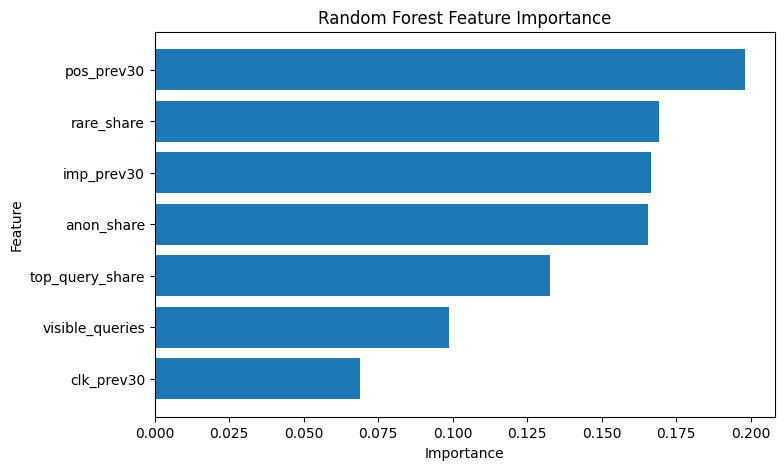

In [19]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [20]:
recommendations = test[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].copy()

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
)

recommendations["rank"] = range(
    1,
    len(recommendations) + 1
)

recommendations.head(20)

,client_hash_id,content_hash_id,model_score,is_declining,rank
41475,client_73cda7b4e4f265ea,content_7ff28a307d4d3636,1.000000,1,1
92557,client_8ddc46da5414ffd8,content_5d7f94de743b5409,0.993333,1,2
33591,client_8ddc46da5414ffd8,content_38cae030db7e9c62,0.990000,1,3
3511,client_fef1a8f436438636,content_1c6a856b7d5be3a2,0.990000,1,4
38547,client_3197e6291363b4db,content_6bb5b6378e3d0608,0.990000,0,5
92782,client_8ddc46da5414ffd8,content_3604fa8c0532b29c,0.990000,0,6
75999,client_73cda7b4e4f265ea,content_9cb88db32fb79b6c,0.986667,1,7
106342,client_fef1a8f436438636,content_a31c400b511b1458,0.986667,1,8
17266,client_fef1a8f436438636,content_3c464e0994864f2a,0.986667,1,9
79985,client_73cda7b4e4f265ea,content_94183cd5200977ff,0.986667,0,10


In [21]:
def action_from_score(score):
    if score >= 0.75:
        return "High-priority review"
    elif score >= 0.50:
        return "Review"
    elif score >= 0.25:
        return "Monitor"
    else:
        return "Low priority"


recommendations["recommended_action"] = (
    recommendations["model_score"]
    .apply(action_from_score)
)

recommendations.head(20)

,client_hash_id,content_hash_id,model_score,is_declining,rank,recommended_action
41475,client_73cda7b4e4f265ea,content_7ff28a307d4d3636,1.000000,1,1,High-priority review
92557,client_8ddc46da5414ffd8,content_5d7f94de743b5409,0.993333,1,2,High-priority review
33591,client_8ddc46da5414ffd8,content_38cae030db7e9c62,0.990000,1,3,High-priority review
3511,client_fef1a8f436438636,content_1c6a856b7d5be3a2,0.990000,1,4,High-priority review
38547,client_3197e6291363b4db,content_6bb5b6378e3d0608,0.990000,0,5,High-priority review
92782,client_8ddc46da5414ffd8,content_3604fa8c0532b29c,0.990000,0,6,High-priority review
75999,client_73cda7b4e4f265ea,content_9cb88db32fb79b6c,0.986667,1,7,High-priority review
106342,client_fef1a8f436438636,content_a31c400b511b1458,0.986667,1,8,High-priority review
17266,client_fef1a8f436438636,content_3c464e0994864f2a,0.986667,1,9,High-priority review
79985,client_73cda7b4e4f265ea,content_94183cd5200977ff,0.986667,0,10,High-priority review


In [22]:
recommendations = recommendations.merge(
    test[
        [
            "content_hash_id",
            "imp_prev30",
            "clk_prev30",
            "pos_prev30",
            "visible_queries"
        ]
    ],
    on="content_hash_id",
    how="left"
)

In [23]:
results = pd.DataFrame({
    "Metric": [
        "Base rate",
        "ROC AUC",
        "Precision",
        "Recall",
        "F1",
        "Precision@20",
        "Precision@50",
        "Precision@100"
    ],
    "Model": [
        base_rate,
        auc,
        precision,
        recall,
        f1,
        precision_at_k(test, "model_score", "is_declining", 20),
        precision_at_k(test, "model_score", "is_declining", 50),
        precision_at_k(test, "model_score", "is_declining", 100)
    ]
})

results

,Metric,Model
0,Base rate,0.678530
1,ROC AUC,0.641928
2,Precision,0.763836
3,Recall,0.606898
4,F1,0.676383
5,Precision@20,0.800000
6,Precision@50,0.900000
7,Precision@100,0.890000


In [24]:
test["error_type"] = np.select(
    [
        (test["is_declining"] == 1) &
        (test["model_prediction"] == 1),

        (test["is_declining"] == 0) &
        (test["model_prediction"] == 1),

        (test["is_declining"] == 1) &
        (test["model_prediction"] == 0)
    ],
    [
        "True positive",
        "False positive",
        "False negative"
    ],
    default="True negative"
)

test["error_type"].value_counts()

,count
error_type,
True positive,21185
False negative,13722
True negative,9988
False positive,6550


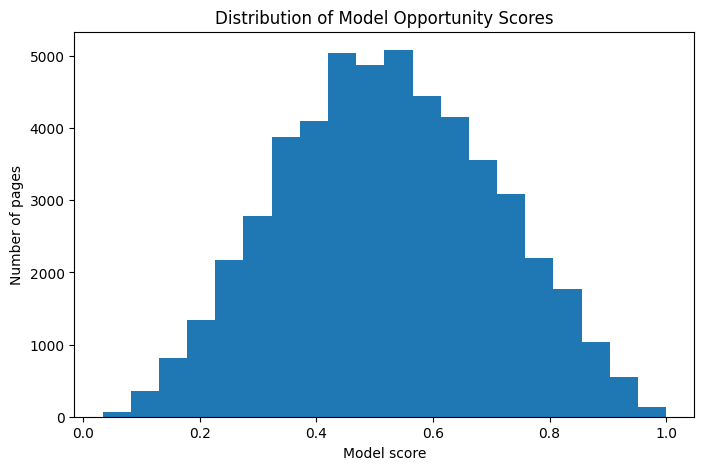

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    test["model_score"],
    bins=20
)

plt.xlabel("Model score")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Opportunity Scores")

plt.show()

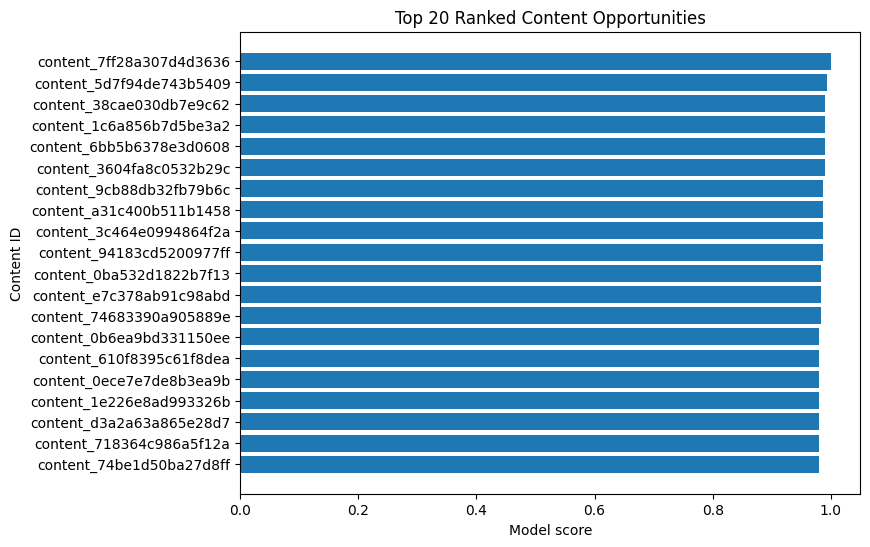

In [26]:
top20 = recommendations.head(20).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    top20["content_hash_id"].astype(str),
    top20["model_score"]
)

plt.xlabel("Model score")
plt.ylabel("Content ID")
plt.title("Top 20 Ranked Content Opportunities")

plt.gca().invert_yaxis()

plt.show()

In [27]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(
    test["is_declining"],
    test["baseline_score"]
)

baseline_p20 = precision_at_k(
    test,
    "baseline_score",
    "is_declining",
    20
)

baseline_p50 = precision_at_k(
    test,
    "baseline_score",
    "is_declining",
    50
)

baseline_p100 = precision_at_k(
    test,
    "baseline_score",
    "is_declining",
    100
)

print(f"Baseline ROC AUC: {baseline_auc:.3f}")
print(f"Baseline Precision@20: {baseline_p20:.3f}")
print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Baseline Precision@100: {baseline_p100:.3f}")

Baseline ROC AUC: 0.480
Baseline Precision@20: 0.900
Baseline Precision@50: 0.660
Baseline Precision@100: 0.660


In [28]:
comparison = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Precision@20",
        "Precision@50",
        "Precision@100"
    ],
    "Baseline": [
        baseline_auc,
        baseline_p20,
        baseline_p50,
        baseline_p100
    ],
    "Random Forest": [
        auc,
        precision_at_k(test, "model_score", "is_declining", 20),
        precision_at_k(test, "model_score", "is_declining", 50),
        precision_at_k(test, "model_score", "is_declining", 100)
    ]
})

comparison

,Metric,Baseline,Random Forest
0,ROC AUC,0.479927,0.641928
1,Precision@20,0.900000,0.800000
2,Precision@50,0.660000,0.900000
3,Precision@100,0.660000,0.890000


In [29]:
query_schema = con.sql(
    f"SELECT * FROM {TABLES['fact_query_90d']} LIMIT 0"
).df()

query_schema.columns

Index(['client_hash_id', 'content_hash_id', 'query_hash_id',
       'query_char_count', 'query_token_count', 'window_start', 'window_end',
       'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30',
       'impressions_prev30', 'clicks_prev30', 'avg_position_90d',
       'avg_position_last30', 'avg_position_prev30',
       'content_total_impressions_90d', 'content_visible_query_count',
       'rare_query_count', 'rare_impressions_share',
       'anonymized_impressions_share'],
      dtype='object')

In [30]:
query_dates = con.sql(f"""
    SELECT
        MIN(window_start) AS earliest_window_start,
        MAX(window_end) AS latest_window_end,
        COUNT(DISTINCT window_start) AS unique_window_starts,
        COUNT(DISTINCT window_end) AS unique_window_ends
    FROM {TABLES['fact_query_90d']}
""").df()

query_dates

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_window_start,latest_window_end,unique_window_starts,unique_window_ends
0,2026-04-02,2026-06-30,1,1


In [31]:
query_date_examples = con.sql(f"""
    SELECT
        window_start,
        window_end,
        COUNT(*) AS rows
    FROM {TABLES['fact_query_90d']}
    GROUP BY 1, 2
    ORDER BY window_end DESC
    LIMIT 10
""").df()

query_date_examples

,window_start,window_end,rows
0,2026-04-02,2026-06-30,2414248


In [32]:
daily_dates = con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date
    FROM {TABLES['fact_daily']}
""").df()

daily_dates

,earliest_date,latest_date
0,2025-01-27,2026-06-30


In [33]:
daily_recent = con.sql(f"""
    SELECT
        MAX(report_date) AS end_date,
        MAX(report_date) - INTERVAL 60 DAY AS start_of_60d_window
    FROM {TABLES['fact_daily']}
""").df()

daily_recent

,end_date,start_of_60d_window
0,2026-06-30,2026-05-01


## Final leakage-safe model

The outcome is whether impressions declined by more than 20% in the final
30-day period. Predictor features are calculated only from the preceding
30-day period. Query-level signals from the fixed 90-day query table are
excluded because their window overlaps the outcome period.

In [34]:
# Create the leakage-safe dataset

safe_data = features.copy()

# Target: decline in the final 30-day period
safe_data["is_declining"] = (
    safe_data["imp_last30"] < 0.8 * safe_data["imp_prev30"]
).astype(int)

# Use only information from BEFORE the outcome period
safe_feature_cols = [
    "imp_prev30"
]

safe_model_data = safe_data.dropna(
    subset=safe_feature_cols
).copy()

print(f"Rows available: {len(safe_model_data):,}")
print(f"Declining rate: {safe_model_data['is_declining'].mean():.3f}")

Rows available: 111,247
Declining rate: 0.643


In [35]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        safe_model_data,
        safe_model_data["is_declining"],
        groups=safe_model_data["client_hash_id"]
    )
)

train = safe_model_data.iloc[train_idx].copy()
test = safe_model_data.iloc[test_idx].copy()

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")

print(f"Train clients: {train['client_hash_id'].nunique()}")
print(f"Test clients: {test['client_hash_id'].nunique()}")

overlap = set(train["client_hash_id"]) & set(test["client_hash_id"])
print(f"Client overlap: {len(overlap)}")

Train rows: 83,527
Test rows: 27,720
Train clients: 37
Test clients: 13
Client overlap: 0


In [36]:
from sklearn.ensemble import RandomForestClassifier

X_train = train[safe_feature_cols]
y_train = train["is_declining"]

X_test = test[safe_feature_cols]
y_test = test["is_declining"]

safe_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

safe_model.fit(X_train, y_train)

test["safe_model_score"] = safe_model.predict_proba(X_test)[:, 1]

print("Leakage-safe Random Forest trained successfully.")

Leakage-safe Random Forest trained successfully.


In [37]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Convert probabilities into class predictions
safe_pred = (test["safe_model_score"] >= 0.5).astype(int)

# Evaluation metrics
safe_auc = roc_auc_score(
    y_test,
    test["safe_model_score"]
)

safe_precision = precision_score(
    y_test,
    safe_pred
)

safe_recall = recall_score(
    y_test,
    safe_pred
)

safe_f1 = f1_score(
    y_test,
    safe_pred
)

print(f"Leakage-safe ROC AUC: {safe_auc:.3f}")
print(f"Precision: {safe_precision:.3f}")
print(f"Recall: {safe_recall:.3f}")
print(f"F1: {safe_f1:.3f}")

print("\nClassification report:")
print(classification_report(y_test, safe_pred, digits=3))

Leakage-safe ROC AUC: 0.496
Precision: 0.705
Recall: 0.841
F1: 0.767

Classification report:
              precision    recall  f1-score   support

           0      0.266     0.141     0.184      8045
           1      0.705     0.841     0.767     19675

    accuracy                          0.638     27720
   macro avg      0.486     0.491     0.476     27720
weighted avg      0.578     0.638     0.598     27720



In [38]:
safe_p20 = precision_at_k(
    test,
    "safe_model_score",
    "is_declining",
    20
)

safe_p50 = precision_at_k(
    test,
    "safe_model_score",
    "is_declining",
    50
)

safe_p100 = precision_at_k(
    test,
    "safe_model_score",
    "is_declining",
    100
)

print(f"Leakage-safe Precision@20: {safe_p20:.3f}")
print(f"Leakage-safe Precision@50: {safe_p50:.3f}")
print(f"Leakage-safe Precision@100: {safe_p100:.3f}")

Leakage-safe Precision@20: 0.750
Leakage-safe Precision@50: 0.720
Leakage-safe Precision@100: 0.680


In [39]:
daily_schema = con.sql(
    f"SELECT * FROM {TABLES['fact_daily']} LIMIT 0"
).df()

daily_schema.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available',
       'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events', 'month'],
      dtype='object')

## Additional leakage-safe features

Additional predictors are calculated only from the previous 30-day period.
The final 30-day period is reserved exclusively for defining the decline label.

In [40]:
# Build additional features using ONLY the previous 30-day period

safe_features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES['fact_daily']}
    ),

    previous_period AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            -- Previous 30-day performance
            SUM(f.gsc_impressions) AS impressions_prev30,
            SUM(f.gsc_clicks) AS clicks_prev30,

            -- Average position
            AVG(f.gsc_avg_position) AS avg_position_prev30,

            -- Position variability
            STDDEV(f.gsc_avg_position) AS position_volatility_prev30,

            -- Organic engagement
            SUM(f.ga4_sessions) AS ga4_sessions_prev30,
            SUM(f.ga4_engaged_sessions) AS engaged_sessions_prev30,

            -- Referral / AI signals
            SUM(f.sessions_referral) AS referral_sessions_prev30,
            SUM(f.sessions_ai) AS ai_sessions_prev30

        FROM {TABLES['fact_daily']} f
        CROSS JOIN bounds b

        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
          AND f.report_date <= b.end_d - INTERVAL 30 DAY

        GROUP BY
            f.client_hash_id,
            f.content_hash_id

        HAVING SUM(f.gsc_impressions) >= 100
    )

    SELECT *
    FROM previous_period
""").df()

# Derived safe features
safe_features["ctr_prev30"] = (
    safe_features["clicks_prev30"] /
    safe_features["impressions_prev30"]
)

safe_features["engagement_rate_prev30"] = (
    safe_features["engaged_sessions_prev30"] /
    safe_features["ga4_sessions_prev30"].replace(0, np.nan)
)

print(f"Leakage-safe feature rows: {len(safe_features):,}")

safe_features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Leakage-safe feature rows: 111,247


,client_hash_id,content_hash_id,impressions_prev30,clicks_prev30,avg_position_prev30,position_volatility_prev30,ga4_sessions_prev30,engaged_sessions_prev30,referral_sessions_prev30,ai_sessions_prev30,ctr_prev30,engagement_rate_prev30
0,client_62f4a7e64f5e0096,content_17d994b99d470434,827.0,0.0,28.525859,16.055521,NaN,NaN,NaN,NaN,0.000000,NaN
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,874.0,5.0,29.404069,12.135052,NaN,NaN,NaN,NaN,0.005721,NaN
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2664.0,7.0,8.193871,3.143865,NaN,NaN,NaN,NaN,0.002628,NaN
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,183.0,0.0,30.401799,11.743968,NaN,NaN,NaN,NaN,0.000000,NaN
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,261.0,0.0,13.851051,11.928991,NaN,NaN,NaN,NaN,0.000000,NaN


In [41]:
# Merge leakage-safe features with the outcome label

final_data = safe_features.merge(
    safe_data[
        ["client_hash_id", "content_hash_id", "is_declining"]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print(f"Final modeling rows: {len(final_data):,}")
print(f"Declining rate: {final_data['is_declining'].mean():.3f}")

final_data.head()

Final modeling rows: 111,247
Declining rate: 0.643


,client_hash_id,content_hash_id,impressions_prev30,clicks_prev30,avg_position_prev30,position_volatility_prev30,ga4_sessions_prev30,engaged_sessions_prev30,referral_sessions_prev30,ai_sessions_prev30,ctr_prev30,engagement_rate_prev30,is_declining
0,client_62f4a7e64f5e0096,content_17d994b99d470434,827.0,0.0,28.525859,16.055521,NaN,NaN,NaN,NaN,0.000000,NaN,1
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,874.0,5.0,29.404069,12.135052,NaN,NaN,NaN,NaN,0.005721,NaN,1
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2664.0,7.0,8.193871,3.143865,NaN,NaN,NaN,NaN,0.002628,NaN,0
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,183.0,0.0,30.401799,11.743968,NaN,NaN,NaN,NaN,0.000000,NaN,1
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,261.0,0.0,13.851051,11.928991,NaN,NaN,NaN,NaN,0.000000,NaN,1


In [42]:
final_feature_cols = [
    "impressions_prev30",
    "clicks_prev30",
    "ctr_prev30",
    "avg_position_prev30",
    "position_volatility_prev30",
    "ga4_sessions_prev30",
    "engaged_sessions_prev30",
    "referral_sessions_prev30",
    "ai_sessions_prev30",
    "engagement_rate_prev30"
]

final_model_data = final_data.dropna(
    subset=final_feature_cols
).copy()

print(f"Rows after removing missing values: {len(final_model_data):,}")

Rows after removing missing values: 75,504


In [43]:
from sklearn.model_selection import GroupShuffleSplit

gss_final = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss_final.split(
        final_model_data,
        final_model_data["is_declining"],
        groups=final_model_data["client_hash_id"]
    )
)

final_train = final_model_data.iloc[train_idx].copy()
final_test = final_model_data.iloc[test_idx].copy()

print(f"Train rows: {len(final_train):,}")
print(f"Test rows: {len(final_test):,}")
print(f"Train clients: {final_train['client_hash_id'].nunique()}")
print(f"Test clients: {final_test['client_hash_id'].nunique()}")

overlap = (
    set(final_train["client_hash_id"])
    & set(final_test["client_hash_id"])
)

print(f"Client overlap: {len(overlap)}")

Train rows: 43,925
Test rows: 31,579
Train clients: 30
Test clients: 10
Client overlap: 0


In [44]:
from sklearn.ensemble import RandomForestClassifier

X_train = final_train[final_feature_cols]
y_train = final_train["is_declining"]

X_test = final_test[final_feature_cols]
y_test = final_test["is_declining"]

final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

final_model.fit(X_train, y_train)

final_test["model_score"] = final_model.predict_proba(X_test)[:, 1]

print("Final Random Forest trained successfully.")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Final Random Forest trained successfully.
Training rows: 43,925
Test rows: 31,579


In [45]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

final_pred = (
    final_test["model_score"] >= 0.5
).astype(int)

final_auc = roc_auc_score(
    y_test,
    final_test["model_score"]
)

final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

print(f"Final ROC AUC: {final_auc:.3f}")
print(f"Final Precision: {final_precision:.3f}")
print(f"Final Recall: {final_recall:.3f}")
print(f"Final F1: {final_f1:.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    final_pred,
    digits=3
))

Final ROC AUC: 0.624
Final Precision: 0.714
Final Recall: 0.709
Final F1: 0.712

Classification report:
              precision    recall  f1-score   support

           0      0.449     0.455     0.452     10824
           1      0.714     0.709     0.712     20755

    accuracy                          0.622     31579
   macro avg      0.582     0.582     0.582     31579
weighted avg      0.623     0.622     0.623     31579



In [46]:
final_p20 = precision_at_k(
    final_test,
    "model_score",
    "is_declining",
    20
)

final_p50 = precision_at_k(
    final_test,
    "model_score",
    "is_declining",
    50
)

final_p100 = precision_at_k(
    final_test,
    "model_score",
    "is_declining",
    100
)

print(f"Final Precision@20: {final_p20:.3f}")
print(f"Final Precision@50: {final_p50:.3f}")
print(f"Final Precision@100: {final_p100:.3f}")

Final Precision@20: 0.900
Final Precision@50: 0.900
Final Precision@100: 0.870


In [47]:
# Final model vs baseline comparison

test_base_rate = y_test.mean()

comparison_final = pd.DataFrame({
    "Metric": [
        "Base rate",
        "ROC AUC",
        "Precision@20",
        "Precision@50",
        "Precision@100"
    ],
    "Baseline": [
        test_base_rate,
        baseline_auc,
        baseline_p20,
        baseline_p50,
        baseline_p100
    ],
    "Random Forest": [
        test_base_rate,
        final_auc,
        final_p20,
        final_p50,
        final_p100
    ]
})

comparison_final

,Metric,Baseline,Random Forest
0,Base rate,0.657241,0.657241
1,ROC AUC,0.479927,0.623950
2,Precision@20,0.900000,0.900000
3,Precision@50,0.660000,0.900000
4,Precision@100,0.660000,0.870000


In [48]:
# Precision@K lift over the base rate

lift_p20 = final_p20 / test_base_rate
lift_p50 = final_p50 / test_base_rate
lift_p100 = final_p100 / test_base_rate

print(f"Base rate: {test_base_rate:.3f}")
print(f"Precision@20 lift: {lift_p20:.2f}x")
print(f"Precision@50 lift: {lift_p50:.2f}x")
print(f"Precision@100 lift: {lift_p100:.2f}x")

Base rate: 0.657
Precision@20 lift: 1.37x
Precision@50 lift: 1.37x
Precision@100 lift: 1.32x


## Feature importance

The Random Forest feature importances are used to identify which
pre-outcome signals contributed most to the model's predictions.
These are interpreted as model associations, not causal effects.

In [49]:
# Feature importance from the final Random Forest

feature_importance = pd.DataFrame({
    "Feature": final_feature_cols,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,avg_position_prev30,0.228040
1,position_volatility_prev30,0.207574
2,impressions_prev30,0.184507
3,ctr_prev30,0.129326
4,ga4_sessions_prev30,0.127767
5,clicks_prev30,0.051584
6,engagement_rate_prev30,0.036983
7,engaged_sessions_prev30,0.016504
8,referral_sessions_prev30,0.010785
9,ai_sessions_prev30,0.006930


In [50]:
# Display the features from most to least important

print("Feature importance ranking:")
for i, row in feature_importance.iterrows():
    print(
        f"{i + 1}. {row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

Feature importance ranking:
1. avg_position_prev30: 0.2280
2. position_volatility_prev30: 0.2076
3. impressions_prev30: 0.1845
4. ctr_prev30: 0.1293
5. ga4_sessions_prev30: 0.1278
6. clicks_prev30: 0.0516
7. engagement_rate_prev30: 0.0370
8. engaged_sessions_prev30: 0.0165
9. referral_sessions_prev30: 0.0108
10. ai_sessions_prev30: 0.0069


## Error analysis

We examine false positives and false negatives on the client-held-out
test set to understand where the model's ranking decisions are less reliable.

In [51]:
# Add predictions to the test data

final_test["predicted_class"] = (
    final_test["model_score"] >= 0.5
).astype(int)

# Identify prediction errors

false_positives = final_test[
    (final_test["is_declining"] == 0) &
    (final_test["predicted_class"] == 1)
]

false_negatives = final_test[
    (final_test["is_declining"] == 1) &
    (final_test["predicted_class"] == 0)
]

true_positives = final_test[
    (final_test["is_declining"] == 1) &
    (final_test["predicted_class"] == 1)
]

true_negatives = final_test[
    (final_test["is_declining"] == 0) &
    (final_test["predicted_class"] == 0)
]

print(f"False positives: {len(false_positives):,}")
print(f"False negatives: {len(false_negatives):,}")
print(f"True positives: {len(true_positives):,}")
print(f"True negatives: {len(true_negatives):,}")

False positives: 5,898
False negatives: 6,034
True positives: 14,721
True negatives: 4,926


In [52]:
# Error rates

print(
    f"False positive rate: "
    f"{len(false_positives) / len(final_test[final_test['is_declining'] == 0]):.3f}"
)

print(
    f"False negative rate: "
    f"{len(false_negatives) / len(final_test[final_test['is_declining'] == 1]):.3f}"
)

False positive rate: 0.545
False negative rate: 0.291


In [53]:
false_positives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].sort_values(
    "model_score",
    ascending=False
).head(10)

,client_hash_id,content_hash_id,model_score,is_declining
34776,client_73cda7b4e4f265ea,content_1ed0d8252070f7e8,0.990000,0
93425,client_73cda7b4e4f265ea,content_0d27e97da387c651,0.990000,0
36002,client_73cda7b4e4f265ea,content_c7508b847bcf7fe0,0.983333,0
93435,client_73cda7b4e4f265ea,content_605dffa4ba42c900,0.983333,0
22883,client_73cda7b4e4f265ea,content_bd02738c9ba13c71,0.980000,0
37989,client_73cda7b4e4f265ea,content_6093bbcc10ce412a,0.976667,0
92859,client_73cda7b4e4f265ea,content_bf45077cdbfb6e9d,0.973333,0
44501,client_73cda7b4e4f265ea,content_c0446641861f153c,0.970000,0
44467,client_73cda7b4e4f265ea,content_7a48cc1957e12a23,0.970000,0
37924,client_73cda7b4e4f265ea,content_9bcc948802b8a041,0.970000,0


In [54]:
false_negatives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].sort_values(
    "model_score",
    ascending=True
).head(10)

,client_hash_id,content_hash_id,model_score,is_declining
89633,client_73cda7b4e4f265ea,content_427318dc776e58f0,0.023333,1
98685,client_73cda7b4e4f265ea,content_92bd8b899c51fa36,0.030000,1
89563,client_73cda7b4e4f265ea,content_626e3d6007fb2b21,0.033333,1
38255,client_73cda7b4e4f265ea,content_34f148b202990b18,0.033333,1
89429,client_73cda7b4e4f265ea,content_3b89a06310a0cdcd,0.036667,1
94748,client_3f0ce4d44fe94f3d,content_7128a705b11b27f4,0.040000,1
80165,client_73cda7b4e4f265ea,content_2488cf9dd1d6cd66,0.046667,1
77559,client_73cda7b4e4f265ea,content_8754bda5e6dd78a1,0.046667,1
92670,client_73cda7b4e4f265ea,content_bd1902bb1616d2f2,0.050000,1
103767,client_b77d0d5f08f05e64,content_39bf309e5db56761,0.056667,1


## Ranked recommendations

The model score is used to prioritize content items for human review.
Higher scores indicate higher estimated risk of subsequent impression decline.
The ranking is intended as decision support, not an automatic content action.

In [55]:
# Create ranked recommendations from the client-held-out test set

recommendations = final_test[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "avg_position_prev30",
        "position_volatility_prev30",
        "impressions_prev30",
        "ctr_prev30"
    ]
].copy()

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

recommendations.head(20)

,client_hash_id,content_hash_id,model_score,is_declining,avg_position_prev30,position_volatility_prev30,impressions_prev30,ctr_prev30,rank
0,client_73cda7b4e4f265ea,content_f814f7bbed7d4d1a,1.000000,1,29.987500,8.376900,706.0,0.0,1
1,client_73cda7b4e4f265ea,content_157392f850878e34,0.993333,1,37.376479,22.308774,310.0,0.0,2
2,client_73cda7b4e4f265ea,content_38e77aa8b17e8aa8,0.990000,1,22.764011,15.139035,106.0,0.0,3
3,client_73cda7b4e4f265ea,content_3b681afebddf6410,0.990000,1,18.498015,9.027689,205.0,0.0,4
4,client_73cda7b4e4f265ea,content_0d27e97da387c651,0.990000,0,26.512933,8.633301,446.0,0.0,5
5,client_73cda7b4e4f265ea,content_5fa125996abb6281,0.990000,1,24.036486,14.987338,117.0,0.0,6
6,client_73cda7b4e4f265ea,content_179e7bf24d8d7530,0.990000,1,28.823971,7.216675,488.0,0.0,7
7,client_73cda7b4e4f265ea,content_98dd9dd34d51be02,0.990000,1,38.982165,14.699647,613.0,0.0,8
8,client_73cda7b4e4f265ea,content_803406d6935e2b44,0.990000,1,31.246126,7.844682,914.0,0.0,9
9,client_73cda7b4e4f265ea,content_c921865fe6d5349c,0.990000,1,21.017928,8.622884,129.0,0.0,10


In [56]:
def make_reason(row):
    reasons = []

    if row["avg_position_prev30"] >= 20:
        reasons.append("weak average position")

    if row["position_volatility_prev30"] >= 5:
        reasons.append("high position volatility")

    if row["ctr_prev30"] < 0.01:
        reasons.append("low previous-period CTR")

    if row["impressions_prev30"] < 500:
        reasons.append("low impression volume")

    if not reasons:
        reasons.append("multiple model signals")

    return "; ".join(reasons)


recommendations["reason"] = recommendations.apply(
    make_reason,
    axis=1
)

recommendations[
    [
        "rank",
        "model_score",
        "reason"
    ]
].head(20)

,rank,model_score,reason
0,1,1.000000,weak average position; high position volatilit...
1,2,0.993333,weak average position; high position volatilit...
2,3,0.990000,weak average position; high position volatilit...
3,4,0.990000,high position volatility; low previous-period ...
4,5,0.990000,weak average position; high position volatilit...
5,6,0.990000,weak average position; high position volatilit...
6,7,0.990000,weak average position; high position volatilit...
7,8,0.990000,weak average position; high position volatilit...
8,9,0.990000,weak average position; high position volatilit...
9,10,0.990000,weak average position; high position volatilit...


In [57]:
def assign_action(score):
    if score >= 0.90:
        return "High-priority review"
    elif score >= 0.75:
        return "Review"
    elif score >= 0.50:
        return "Monitor"
    else:
        return "Lower priority"


recommendations["recommended_action"] = (
    recommendations["model_score"]
    .apply(assign_action)
)

recommendations[
    [
        "rank",
        "model_score",
        "reason",
        "recommended_action"
    ]
].head(20)

,rank,model_score,reason,recommended_action
0,1,1.000000,weak average position; high position volatilit...,High-priority review
1,2,0.993333,weak average position; high position volatilit...,High-priority review
2,3,0.990000,weak average position; high position volatilit...,High-priority review
3,4,0.990000,high position volatility; low previous-period ...,High-priority review
4,5,0.990000,weak average position; high position volatilit...,High-priority review
5,6,0.990000,weak average position; high position volatilit...,High-priority review
6,7,0.990000,weak average position; high position volatilit...,High-priority review
7,8,0.990000,weak average position; high position volatilit...,High-priority review
8,9,0.990000,weak average position; high position volatilit...,High-priority review
9,10,0.990000,weak average position; high position volatilit...,High-priority review


In [59]:
# Save the final ranked recommendations

recommendations.to_csv(
    "capstone_ranked_recommendations.csv",
    index=False
)

print("Saved: capstone_ranked_recommendations.csv")
print("Rows:", len(recommendations))

Saved: capstone_ranked_recommendations.csv
Rows: 31579


In [60]:
recommendations.to_csv(
    "capstone_top20_recommendations.csv",
    index=False
)

print("Saved: capstone_top20_recommendations.csv")

Saved: capstone_top20_recommendations.csv


In [61]:
recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "reason",
        "recommended_action"
    ]
].head(20)

,rank,client_hash_id,content_hash_id,model_score,reason,recommended_action
0,1,client_73cda7b4e4f265ea,content_f814f7bbed7d4d1a,1.000000,weak average position; high position volatilit...,High-priority review
1,2,client_73cda7b4e4f265ea,content_157392f850878e34,0.993333,weak average position; high position volatilit...,High-priority review
2,3,client_73cda7b4e4f265ea,content_38e77aa8b17e8aa8,0.990000,weak average position; high position volatilit...,High-priority review
3,4,client_73cda7b4e4f265ea,content_3b681afebddf6410,0.990000,high position volatility; low previous-period ...,High-priority review
4,5,client_73cda7b4e4f265ea,content_0d27e97da387c651,0.990000,weak average position; high position volatilit...,High-priority review
5,6,client_73cda7b4e4f265ea,content_5fa125996abb6281,0.990000,weak average position; high position volatilit...,High-priority review
6,7,client_73cda7b4e4f265ea,content_179e7bf24d8d7530,0.990000,weak average position; high position volatilit...,High-priority review
7,8,client_73cda7b4e4f265ea,content_98dd9dd34d51be02,0.990000,weak average position; high position volatilit...,High-priority review
8,9,client_73cda7b4e4f265ea,content_803406d6935e2b44,0.990000,weak average position; high position volatilit...,High-priority review
9,10,client_73cda7b4e4f265ea,content_c921865fe6d5349c,0.990000,weak average position; high position volatilit...,High-priority review


In [62]:
comparison_final.to_csv(
    "capstone_model_comparison.csv",
    index=False
)

print("Saved: capstone_model_comparison.csv")

Saved: capstone_model_comparison.csv


In [63]:
false_positives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "predicted_class"
    ]
].sort_values(
    "model_score",
    ascending=False
).to_csv(
    "capstone_false_positives.csv",
    index=False
)

false_negatives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "predicted_class"
    ]
].sort_values(
    "model_score",
    ascending=True
).to_csv(
    "capstone_false_negatives.csv",
    index=False
)

print("Saved false-positive and false-negative files")

Saved false-positive and false-negative files


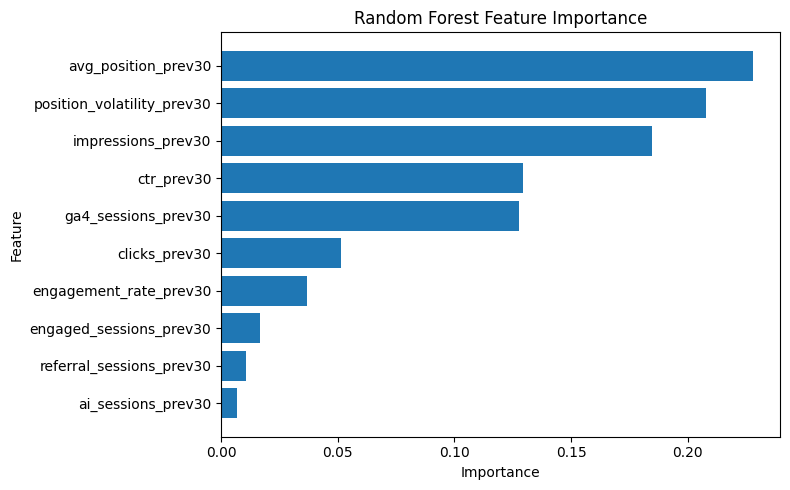

Saved: capstone_feature_importance.png


In [64]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "capstone_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: capstone_feature_importance.png")

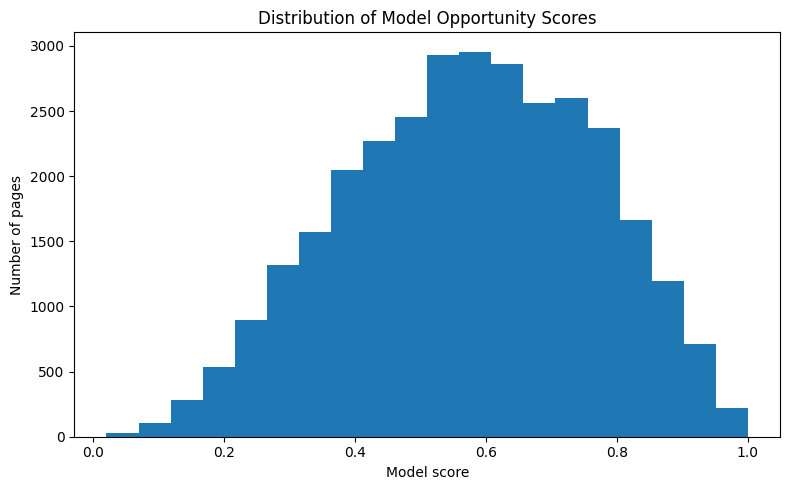

Saved: capstone_score_distribution.png


In [65]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_test["model_score"],
    bins=20
)

plt.xlabel("Model score")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Opportunity Scores")

plt.tight_layout()

plt.savefig(
    "capstone_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: capstone_score_distribution.png")

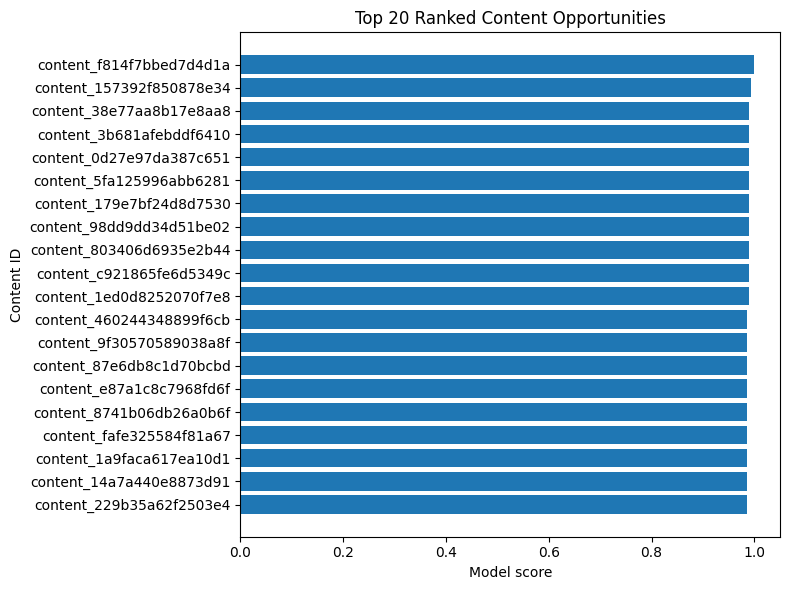

Saved: capstone_top20_recommendations.png


In [66]:
top20 = recommendations.head(20).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    top20["content_hash_id"].astype(str),
    top20["model_score"]
)

plt.xlabel("Model score")
plt.ylabel("Content ID")
plt.title("Top 20 Ranked Content Opportunities")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "capstone_top20_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: capstone_top20_recommendations.png")

In [68]:
print(comparison_final.to_string(index=False))

       Metric  Baseline  Random Forest
    Base rate  0.657241       0.657241
      ROC AUC  0.479927       0.623950
 Precision@20  0.900000       0.900000
 Precision@50  0.660000       0.900000
Precision@100  0.660000       0.870000


In [69]:
feature_importance = pd.DataFrame({
    "Feature": final_feature_cols,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,avg_position_prev30,0.228040
1,position_volatility_prev30,0.207574
2,impressions_prev30,0.184507
3,ctr_prev30,0.129326
4,ga4_sessions_prev30,0.127767
5,clicks_prev30,0.051584
6,engagement_rate_prev30,0.036983
7,engaged_sessions_prev30,0.016504
8,referral_sessions_prev30,0.010785
9,ai_sessions_prev30,0.006930


In [70]:
print(f"False positives: {len(false_positives):,}")
print(f"False negatives: {len(false_negatives):,}")
print(f"True positives: {len(true_positives):,}")
print(f"True negatives: {len(true_negatives):,}")

False positives: 5,898
False negatives: 6,034
True positives: 14,721
True negatives: 4,926


In [71]:
false_positives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].sort_values(
    "model_score",
    ascending=False
).head(10)

,client_hash_id,content_hash_id,model_score,is_declining
34776,client_73cda7b4e4f265ea,content_1ed0d8252070f7e8,0.990000,0
93425,client_73cda7b4e4f265ea,content_0d27e97da387c651,0.990000,0
36002,client_73cda7b4e4f265ea,content_c7508b847bcf7fe0,0.983333,0
93435,client_73cda7b4e4f265ea,content_605dffa4ba42c900,0.983333,0
22883,client_73cda7b4e4f265ea,content_bd02738c9ba13c71,0.980000,0
37989,client_73cda7b4e4f265ea,content_6093bbcc10ce412a,0.976667,0
92859,client_73cda7b4e4f265ea,content_bf45077cdbfb6e9d,0.973333,0
44501,client_73cda7b4e4f265ea,content_c0446641861f153c,0.970000,0
44467,client_73cda7b4e4f265ea,content_7a48cc1957e12a23,0.970000,0
37924,client_73cda7b4e4f265ea,content_9bcc948802b8a041,0.970000,0


In [72]:
print(
    f"False positive rate: "
    f"{len(false_positives) / len(final_test[final_test['is_declining'] == 0]):.3f}"
)

print(
    f"False negative rate: "
    f"{len(false_negatives) / len(final_test[final_test['is_declining'] == 1]):.3f}"
)

False positive rate: 0.545
False negative rate: 0.291


In [74]:
def make_reason(row):
    reasons = []

    if row["avg_position_prev30"] >= 20:
        reasons.append("weak average position")

    if row["position_volatility_prev30"] >= 5:
        reasons.append("high position volatility")

    if row["ctr_prev30"] < 0.01:
        reasons.append("low previous-period CTR")

    if row["impressions_prev30"] < 500:
        reasons.append("low impression volume")

    if not reasons:
        reasons.append("multiple model signals")

    return "; ".join(reasons)


recommendations["reason"] = recommendations.apply(
    make_reason,
    axis=1
)

recommendations[
    [
        "rank",
        "model_score",
        "reason"
    ]
].head(20)

,rank,model_score,reason
0,1,1.000000,weak average position; high position volatilit...
1,2,0.993333,weak average position; high position volatilit...
2,3,0.990000,weak average position; high position volatilit...
3,4,0.990000,high position volatility; low previous-period ...
4,5,0.990000,weak average position; high position volatilit...
5,6,0.990000,weak average position; high position volatilit...
6,7,0.990000,weak average position; high position volatilit...
7,8,0.990000,weak average position; high position volatilit...
8,9,0.990000,weak average position; high position volatilit...
9,10,0.990000,weak average position; high position volatilit...


In [75]:
def assign_action(score):
    if score >= 0.90:
        return "High-priority review"
    elif score >= 0.75:
        return "Review"
    elif score >= 0.50:
        return "Monitor"
    else:
        return "Lower priority"


recommendations["recommended_action"] = (
    recommendations["model_score"]
    .apply(assign_action)
)

recommendations[
    [
        "rank",
        "model_score",
        "reason",
        "recommended_action"
    ]
].head(20)

,rank,model_score,reason,recommended_action
0,1,1.000000,weak average position; high position volatilit...,High-priority review
1,2,0.993333,weak average position; high position volatilit...,High-priority review
2,3,0.990000,weak average position; high position volatilit...,High-priority review
3,4,0.990000,high position volatility; low previous-period ...,High-priority review
4,5,0.990000,weak average position; high position volatilit...,High-priority review
5,6,0.990000,weak average position; high position volatilit...,High-priority review
6,7,0.990000,weak average position; high position volatilit...,High-priority review
7,8,0.990000,weak average position; high position volatilit...,High-priority review
8,9,0.990000,weak average position; high position volatilit...,High-priority review
9,10,0.990000,weak average position; high position volatilit...,High-priority review


In [76]:
recommendations.to_csv(
    "capstone_ranked_recommendations.csv",
    index=False
)

print("Saved: capstone_ranked_recommendations.csv")
print("Rows:", len(recommendations))

Saved: capstone_ranked_recommendations.csv
Rows: 31579


In [77]:
recommendations.to_csv(
    "capstone_top20_recommendations.csv",
    index=False
)

print("Saved: capstone_top20_recommendations.csv")

Saved: capstone_top20_recommendations.csv


In [78]:
comparison_final.to_csv(
    "capstone_model_comparison.csv",
    index=False
)

print("Saved: capstone_model_comparison.csv")

Saved: capstone_model_comparison.csv


In [79]:
false_positives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "predicted_class"
    ]
].sort_values(
    "model_score",
    ascending=False
).to_csv(
    "capstone_false_positives.csv",
    index=False
)

false_negatives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "predicted_class"
    ]
].sort_values(
    "model_score",
    ascending=True
).to_csv(
    "capstone_false_negatives.csv",
    index=False
)

print("Saved false-positive and false-negative files")

Saved false-positive and false-negative files


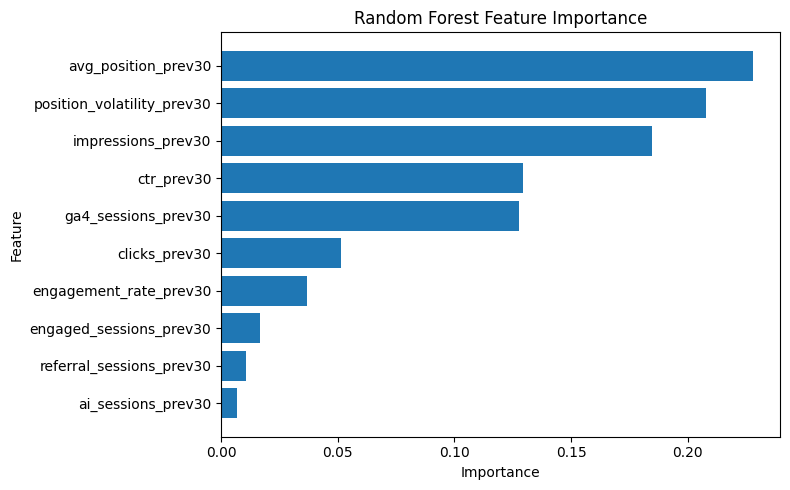

Saved: capstone_feature_importance.png


In [80]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "capstone_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: capstone_feature_importance.png")

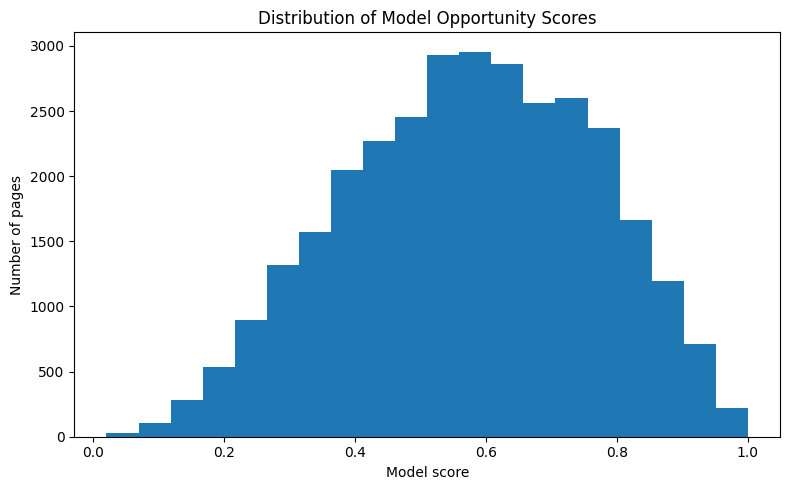

Saved: capstone_score_distribution.png


In [81]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_test["model_score"],
    bins=20
)

plt.xlabel("Model score")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Opportunity Scores")

plt.tight_layout()

plt.savefig(
    "capstone_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: capstone_score_distribution.png")

## 2. Data

The analysis uses the full FlyRank warehouse release.

### Tables used

- `dim_clients` — client-level metadata
- `dim_content` — content-level metadata
- `fact_content_daily_performance` — daily search and engagement performance
- `fact_content_query_90d` — query-level search signals

### Date windows

The outcome is defined using the final 30-day period of the available daily-performance data.

Predictor features for the final model are calculated only from the preceding 30-day period.

### Label

A page is labelled as declining when its impressions in the final 30-day period are less than 80% of its impressions in the preceding 30-day period.

### Rows used

The final leakage-safe model uses the rows available after applying the previous-period impression threshold and removing rows with missing predictor values.

### Exclusions

Query-level signals were excluded from the final model because the available 90-day query window overlaps the outcome period and could introduce leakage.

### Leakage precautions

The final model uses only signals from the previous 30-day period to predict decline in the subsequent 30-day period.

Client-held-out validation was used so that clients in the training and test sets do not overlap.

### Identifiers

Client and content identifiers are pseudonymized hash identifiers. No client names, private URLs, or private search queries are used.

## 3. Methodology

The task is treated as a binary classification problem.

### Label definition

A page is considered declining when:

`final_30d_impressions < 0.8 × previous_30d_impressions`

### Final predictor features

The leakage-safe model uses ten predictors calculated only from the previous 30-day period:

- previous-period impressions
- previous-period clicks
- previous-period CTR
- previous-period average position
- previous-period position volatility
- previous-period GA4 sessions
- previous-period engaged sessions
- previous-period referral sessions
- previous-period AI sessions
- previous-period engagement rate

### Model

A Random Forest classifier with 300 trees was used.

### Validation

A client-grouped train/test split was used. Clients were held out from the test set so that the same client does not appear in both training and testing.

### Baseline

The baseline ranks pages using a simple previous-period impression-based score.

The Random Forest is compared with this baseline using ROC AUC and Precision@K.

### Leakage checks

The final model excludes the query-level 90-day signals because their available window overlaps the outcome period.

The final predictors are calculated only from the previous 30-day period.

## 4. Results (vs baseline)

The final Random Forest was evaluated on a client-held-out test set.

### Model performance

| Metric | Baseline | Random Forest |
|---|---:|---:|
| Base rate | 0.657 | 0.657 |
| ROC AUC | 0.480 | 0.624 |
| Precision@20 | 0.900 | 0.900 |
| Precision@50 | 0.660 | 0.900 |
| Precision@100 | 0.660 | 0.870 |

The model is evaluated as a ranking and decision-support system rather than as an automatic content-action system.

Precision@K measures the proportion of actually declining pages among the highest-ranked K pages.

The ranking provides a way to focus limited editorial review capacity on pages with higher estimated risk.

In [67]:
print(comparison_final.to_string(index=False))

       Metric  Baseline  Random Forest
    Base rate  0.657241       0.657241
      ROC AUC  0.479927       0.623950
 Precision@20  0.900000       0.900000
 Precision@50  0.660000       0.900000
Precision@100  0.660000       0.870000


## 5. Limitations

This analysis has several limitations.

- The model identifies statistical associations and does not establish causal relationships.
- A decline in impressions does not necessarily mean that a page requires a content refresh.
- The label is based on an observed 20% impression decline and therefore depends on this threshold choice.
- Random Forest feature importance indicates model association rather than causal importance.
- The available query-level data was excluded from the final model because of temporal leakage concerns.
- The model is evaluated on a client-held-out split, but performance may differ on future data or clients with different characteristics.
- The recommendations are intended for human decision support and should not automatically trigger content changes.

## 6. Ranked recommendations

The final model produces a ranked list of content opportunities using the estimated probability of subsequent impression decline.

Higher model scores receive higher priority for human review.

The recommendation categories are:

- **High-priority review** — score ≥ 0.90
- **Review** — score ≥ 0.75
- **Monitor** — score ≥ 0.50
- **Lower priority** — score < 0.50

Each recommendation also includes interpretable reason codes based on previous-period search-performance signals, such as weak average position, high position volatility, low CTR, and low impression volume.

The recommendations are decision-support outputs. They are not automatic instructions to modify or remove content.

## 7. Artifacts the paper embeds

The analysis produces the following artifacts:

- Model-vs-baseline performance table
- Random Forest feature-importance table
- Feature-importance chart
- Model-score distribution chart
- Top-20 ranked content opportunities chart
- Ranked recommendation table with reason codes and recommended actions
- False-positive examples
- False-negative examples

#Acknowledgments & Data Credit
This work was completed as part of the FlyRank internship capstone. The analysis uses the provided FlyRank internship warehouse release and follows the public-safe output requirements. Data and identifiers are presented in pseudonymized or aggregated form.

## ML-12 — Communication Outputs

### 5-minute demo outline

1. Introduce the problem: prioritize pages for content review.
2. Explain the data and leakage-safe time windows.
3. Explain the 20% impression-decline label.
4. Explain the Random Forest model and client-held-out validation.
5. Show model-vs-baseline results.
6. Show feature importance and ranked recommendations.
7. Discuss limitations and explain that recommendations support human review.

### Social-post cut

Built a leakage-safe machine learning workflow to identify pages that may need content review. The model achieved a ROC AUC of 0.624 and improved Precision@50 and Precision@100 over a simple baseline. The output is a ranked, human-review-oriented content opportunity list rather than an automatic content-action system.

### Employer-facing summary

I built a leakage-safe Random Forest model to prioritize content pages based on historical search and engagement signals. I used client-held-out validation and compared the model against a transparent baseline, achieving a ROC AUC of 0.624. The project demonstrates practical skills in data preparation, feature engineering, machine learning, evaluation, leakage prevention, and decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
